# ML Prediction of Stock Price Timeseries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import backtrader as bt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

Get data from some tickers in a diversified portfolio.

In [2]:
tickers = [
    # Tech
    "AAPL","MSFT",
    # Finance
    "JPM","BAC",
    # Healthcare
    "JNJ","PFE",
    # Energy
    "XOM","CVX",
]

In [3]:
datas = [yf.download(i, start='2015-01-01', end='2021-01-01') for i in tickers]
for data in datas:
    data.columns = [col[0] for col in data.columns.values]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
class CollectIndicators(bt.Strategy):
    '''
    Strat for using bt to evaluate indicator values.
    '''
    def __init__(self):

        # -------- Trend --------
        self.sma_10 = bt.indicators.SMA(self.data.close, period=10)
        self.sma_20 = bt.indicators.SMA(self.data.close, period=20)
        self.sma_50 = bt.indicators.SMA(self.data.close, period=50)

        self.ema_10 = bt.indicators.EMA(self.data.close, period=10)
        self.ema_20 = bt.indicators.EMA(self.data.close, period=20)

        self.dema = bt.indicators.DEMA(self.data.close, period=20)
        self.tema = bt.indicators.TEMA(self.data.close, period=20)

        # -------- Momentum --------
        self.rsi = bt.indicators.RSI(self.data.close, period=14)

        self.stoch = bt.indicators.Stochastic(self.data)
        self.williams = bt.indicators.WilliamsR(self.data)

        self.roc = bt.indicators.ROC(self.data.close, period=12)
        self.momentum = bt.indicators.Momentum(self.data.close, period=10)

        # -------- MACD --------
        self.macd = bt.indicators.MACD(self.data.close)

        # -------- Volatility --------
        self.atr = bt.indicators.ATR(self.data, period=14)

        self.bbands = bt.indicators.BollingerBands(self.data.close, period=20)

        # -------- Trend Strength --------
        self.adx = bt.indicators.ADX(self.data, period=14)
        self.plus_di = bt.indicators.PlusDI(self.data, period=14)
        self.minus_di = bt.indicators.MinusDI(self.data, period=14)

        # -------- Volume --------
        #self.obv = bt.indicators.OnBalanceVolume(self.data)
        self.vol_sma = bt.indicators.SMA(self.data.volume, period=20)

        # -------- Features storage --------
        self.features = []

    def next(self):

        self.features.append({

            # Raw price context (useful for ML)
            'CLOSE': self.data.close[0],
            'HIGH': self.data.high[0],
            'LOW': self.data.low[0],
            'VOLUME': self.data.volume[0],

            # Trend
            'SMA10': self.sma_10[0],
            'SMA20': self.sma_20[0],
            'SMA50': self.sma_50[0],
            'EMA10': self.ema_10[0],
            'EMA20': self.ema_20[0],
            'DEMA': self.dema[0],
            'TEMA': self.tema[0],

            # Momentum
            'RSI': self.rsi[0],
            'STOCH_K': self.stoch.percK[0],
            'STOCH_D': self.stoch.percD[0],
            'WILLR': self.williams[0],
            'ROC': self.roc[0],
            'MOM': self.momentum[0],

            # MACD
            'MACD': self.macd.macd[0],
            'MACD_SIGNAL': self.macd.signal[0],
            'MACD_HIST': self.macd.macd[0] - self.macd.signal[0],

            # Volatility
            'ATR': self.atr[0],
            'BB_TOP': self.bbands.top[0],
            'BB_MID': self.bbands.mid[0],
            'BB_BOT': self.bbands.bot[0],

            # Trend strength
            'ADX': self.adx[0],
            'PLUS_DI': self.plus_di[0],
            'MINUS_DI': self.minus_di[0],

            # Volume
            #'OBV': self.obv[0],
            'VOL_SMA': self.vol_sma[0],

        })

In [ ]:
def eval_indicators(df, strat):
    '''
    Evaluate bt indicator values for a data frame.
    '''
    cerebro = bt.Cerebro()
    cerebro.addstrategy(strat)
    data_feed = bt.feeds.PandasData(dataname=df,
            open='Open',
            high='High',
            low='Low',
            close='Close',
            volume='Volume',
            openinterest=None)
    cerebro.adddata(data_feed)
    result = cerebro.run()
    features = pd.DataFrame(result[0].features)
    return features

In [ ]:
# format data frame

datas_feat = [eval_indicators(d, CollectIndicators) for d in datas]
for i in range(len(datas)):
    datas_feat[i].insert(0, 'ticker', tickers[i])
df = pd.concat(datas_feat)

In [13]:
list(map(len, datas))

[1511, 1511, 1511, 1511, 1511, 1511, 1511, 1511]

In [14]:
1511*.9

1359.9

In [ ]:
# train/test split

df_tr = pd.concat( [df[df['ticker'] == ticker].iloc[0:1260] for ticker in tickers] )
df_te = pd.concat( [df[df['ticker'] == ticker].iloc[1260:] for ticker in tickers] )

In [ ]:
# standardize x data with training set parameters

tr_scalerx = StandardScaler()
x_scaler = tr_scalerx.fit(df_tr.iloc[:,2:])

tr_x_sc = x_scaler.transform(df_tr.iloc[:,2:])
te_x_sc = x_scaler.transform(df_te.iloc[:,2:])

tr_y = df_tr['CLOSE']
te_y = df_te['CLOSE']

In [ ]:
# train a RFR

regr = RandomForestRegressor(max_depth=10, random_state=0)
regr.fit(tr_x_sc, tr_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
# R^2 isn't too bad

regr.score(te_x_sc, te_y)

0.9682149203102964

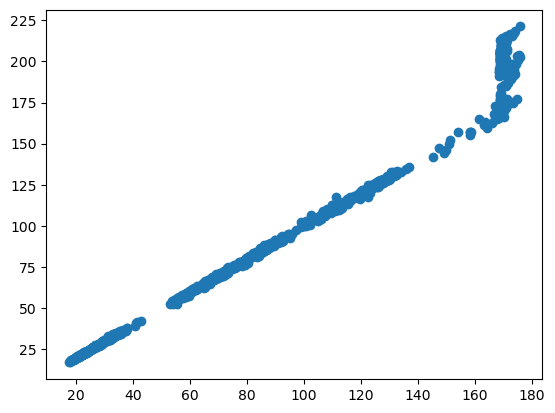

In [ ]:
# but there's a region where prediction is failing

plt.scatter( regr.predict(te_x_sc), te_y )

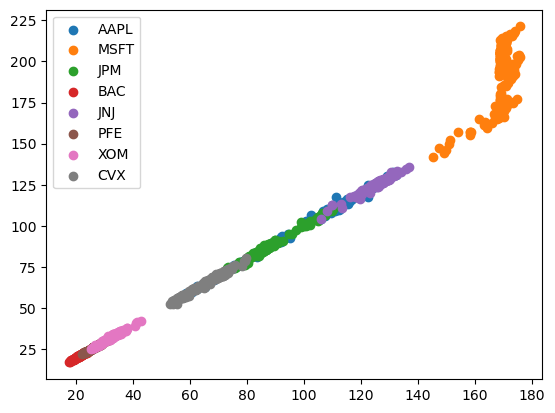

In [ ]:
# this region is due to MSFT only

for i in range(len(tickers)):
    plt.scatter( regr.predict(x_scaler.transform(df_te[df_te['ticker']==tickers[i]].iloc[:,2:])),
            df_te[df_te['ticker']==tickers[i]]['CLOSE'], label=tickers[i] )
plt.legend()
plt.show()

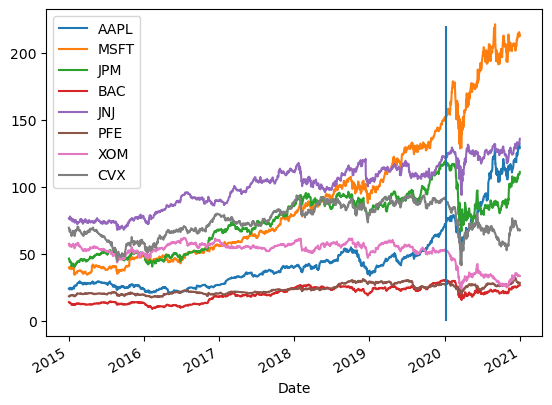

In [ ]:
# indeed, the trend for MSFT changes qualitatively in the test split

for i in range(len(datas)):
    datas[i]['Close'].plot(label=tickers[i])
plt.vlines(datas[0].index[1260],0,220)
plt.legend()
plt.show()